
# HR Employee Attrition Analysis

**Objective:** Analyze employee data to understand why employees leave the company and identify
which factors most strongly predict attrition, in order to recommend data-driven retention strategies.

**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle) — 1,470 employee records, 35 features.

**Tools used:** Python (Pandas, NumPy, Matplotlib, Seaborn) for cleaning and EDA;
SQL for querying; Power BI for the final interactive dashboard.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Load the dataset
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [24]:
pd.set_option('display.max_columns', None)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


**Step 1: Initial Inspection**

In [25]:
print(df.shape)          # rows, columns


(1470, 35)


In [26]:
print(df.info())         # data types, non-null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [27]:
print(df.describe())     # summary stats for numeric columns


               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [28]:
print(df.isnull().sum()) # missing values per column

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## 1. Data Cleaning

Before analysis, the raw dataset was checked for data quality issues. This included checking for
missing values, duplicate rows, inconsistent categories, and columns that carry no analytical value
(e.g., columns where every employee has the same value). This step ensures the analysis that follows
is based on accurate, usable data.

**Step 2: Data Cleaning**

2a. Check and remove duplicate rows

In [29]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


2b. Drop useless/constant columns

In [30]:
# These columns typically have only ONE unique value across all rows — no analytical value
for col in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']:
    print(col, df[col].nunique())

df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])
# Keep EmployeeNumber only if you plan to use it as a unique ID/key

EmployeeCount 1
StandardHours 1
Over18 1
EmployeeNumber 1470


2c. Handle missing values (if any)

In [31]:
# This dataset is usually clean, but always check
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

# If missing values exist:
# Numeric -> fill with median (robust to outliers)
# df['ColumnName'] = df['ColumnName'].fillna(df['ColumnName'].median())

# Categorical -> fill with mode or 'Unknown'
# df['ColumnName'] = df['ColumnName'].fillna(df['ColumnName'].mode()[0])

Series([], dtype: int64)


2d. Fix data types

In [32]:
# Convert Yes/No columns to proper categorical or binary for easier analysis
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime_Flag'] = df['OverTime'].map({'Yes': 1, 'No': 0})

2e. Check for outliers

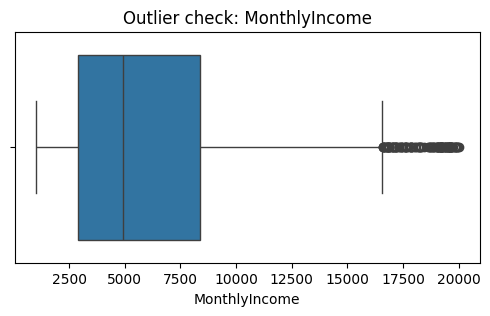

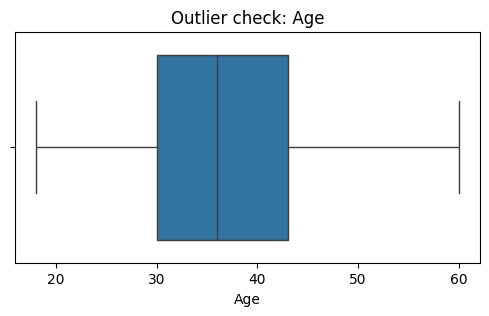

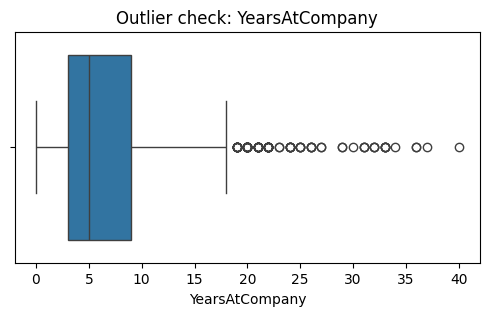

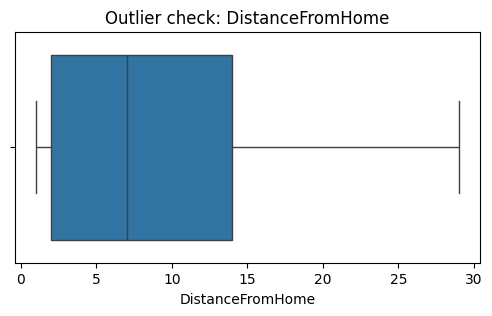

In [33]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in ['MonthlyIncome', 'Age', 'YearsAtCompany', 'DistanceFromHome']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier check: {col}')
    plt.show()

**Result:** The dataset had no missing values and no duplicate rows. Three constant columns
(`EmployeeCount`, `StandardHours`, `Over18`) were removed since they showed no variation across
any employee and therefore add no analytical value. The `Attrition` column was converted into a
numeric `Attrition_Flag` (1/0) to make percentage calculations easier in later steps.

Step 3: Exploratory Data Analysis (EDA)

## 2. Exploratory Data Analysis (EDA)

With the data cleaned, the next step is to explore it — looking for patterns and relationships that
explain why employees leave. Rather than generating charts at random, each analysis below starts with
a specific business question, followed by the relevant chart, and ends with the insight it reveals.

3a. Overall attrition rate

### Business Question: What percentage of employees have left the company?

**Insight:** The overall attrition rate is **16.12%** — 237 out of 1,470 employees have left.
This is the baseline rate against which all other findings should be compared.

In [34]:
attrition_rate = df['Attrition_Flag'].mean() * 100
print(f"Overall attrition rate: {attrition_rate:.2f}%")

Overall attrition rate: 16.12%


3b. Attrition by Department

### Business Question: Does attrition vary by department?

**Insight:** **Sales** has the highest attrition rate at **20.6%**, followed by Human Resources at
**19.0%**, while Research & Development has the lowest at **13.8%**. This suggests Sales may have
working conditions or role pressures that are pushing more employees to leave than other departments.

**Recommendation:** HR should investigate Sales-specific factors — workload, targets, or management
style — that may be contributing to the higher exit rate.

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition_Flag, dtype: float64


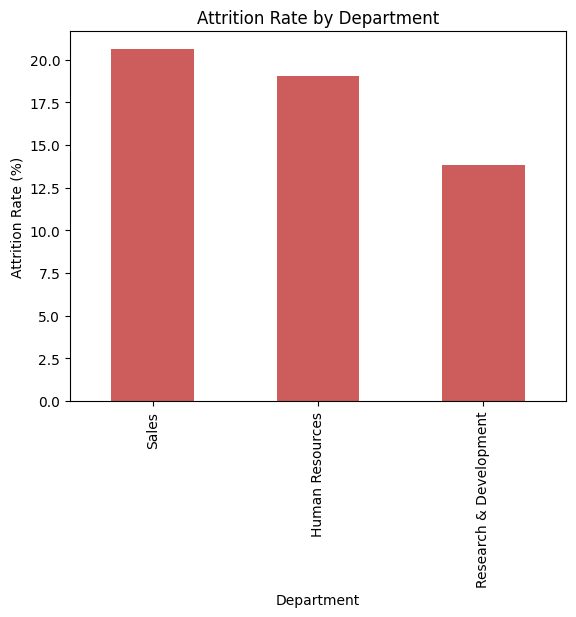

In [35]:
dept_attrition = df.groupby('Department')['Attrition_Flag'].mean().sort_values(ascending=False) * 100
print(dept_attrition)

dept_attrition.plot(kind='bar', color='indianred')
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.show()

3c. Attrition by Overtime

### Business Question: Does working overtime increase the likelihood of leaving?

**Insight:** Employees who work overtime leave at a rate of **30.5%**, compared to just **10.4%**
for those who don't — nearly a 3x difference. This is the single strongest factor found in this analysis.

**Recommendation:** Management should review workload distribution and consider interventions for
employees who consistently work overtime, as this group is at significantly higher risk of leaving.

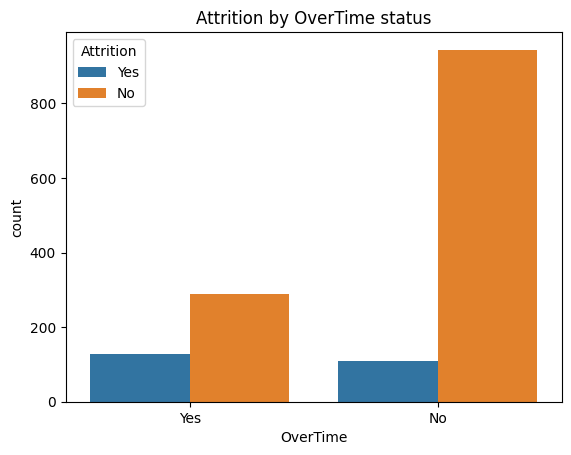

In [36]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Attrition by OverTime status')
plt.show()

3d. Income distribution vs Attrition

### Business Question: Is pay related to attrition?

**Insight:** Employees who left earned an average of **$4,787/month**, compared to **$6,833/month**
for those who stayed. Lower-paid employees are leaving at a higher rate, suggesting compensation
may be a contributing factor, especially when combined with other stressors like overtime.

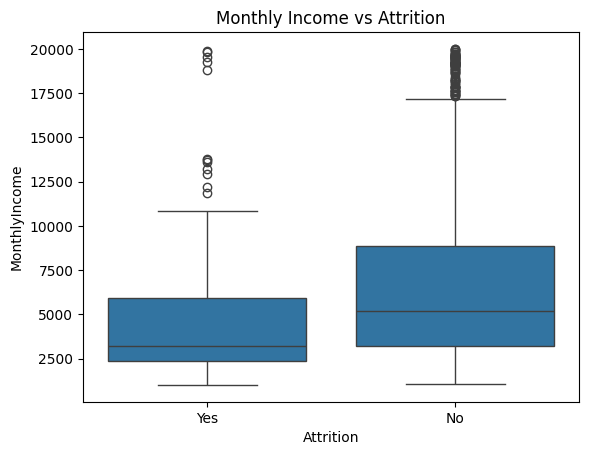

In [37]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

3e. Correlation heatmap (numeric features)

### Business Question: Which numeric factors are most strongly associated with attrition?

**Insight:** OverTime, Total Working Years, Job Level, Years in Current Role, and Monthly Income
showed the strongest correlations with attrition. Employees with less experience, lower job levels,
and overtime work are consistently more likely to leave — reinforcing the findings above with a
statistical view across all variables at once.

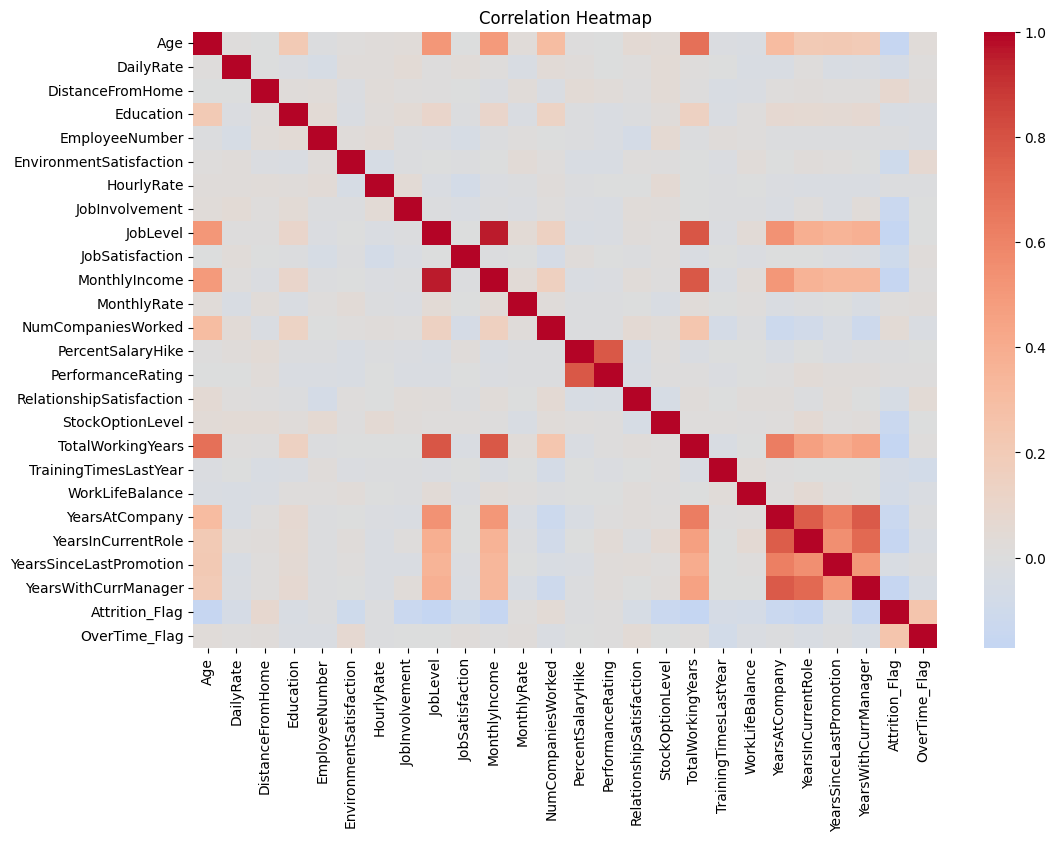

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

3f. Age distribution by Attrition

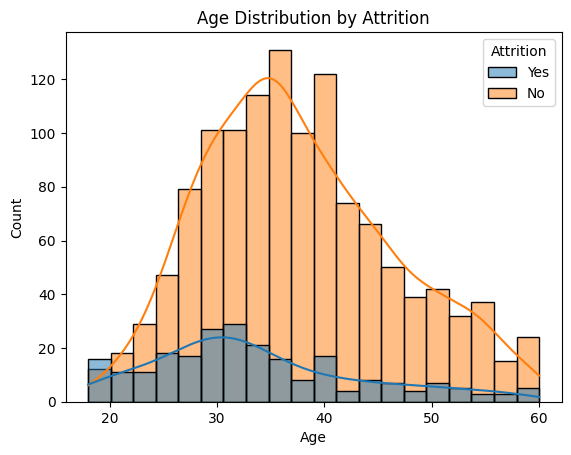

In [39]:
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, bins=20)
plt.title('Age Distribution by Attrition')
plt.show()

3g. Job Satisfaction vs Attrition

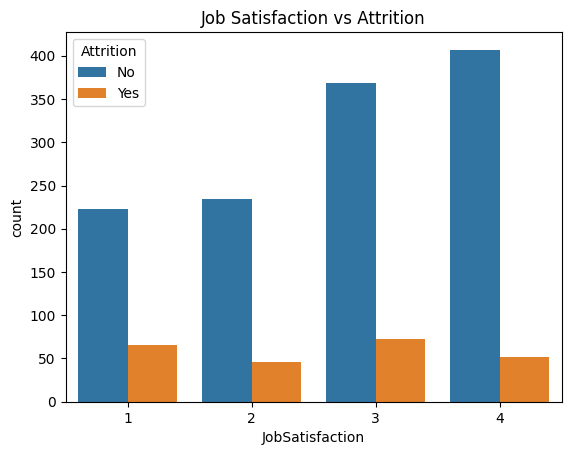

In [40]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title('Job Satisfaction vs Attrition')
plt.show()

**Step 4: Summarize Key Insights**
## Conclusion & Summary of Findings

1. Overall attrition rate: **16.12%**
2. Highest-risk department: **Sales (20.6%)**
3. Overtime nearly triples attrition risk (**30.5% vs 10.4%**)
4. Early tenure (0-2 yrs) is the highest-risk period (**28.9%**, dropping to 8.1% at 10+ years)
5. Lower income and lower satisfaction both correlate with higher attrition
6. Highest-risk combined group: **Sales employees working overtime (37.5%)**

**Overall recommendation:** HR should prioritize retention efforts on early-tenure employees and
those working overtime, particularly within the Sales department, as these factors compound to create
the highest attrition risk in the organization.

**Next steps:** These insights were also explored in SQL and visualized in an interactive Power BI
dashboard (see `/dashboard` folder / linked below) for stakeholder-facing reporting.

**Step 5: Export the cleaned dataset (for Power BI)**

In [41]:
df.to_csv('HR_Attrition_Cleaned.csv', index=False)